# DST Parser Tutorial

This notebook provides a comprehensive guide to using the `dstparser` package for Telescope Array surface detector data analysis.

## Overview

The `dstparser` package provides two main parsing approaches:
1. **Structured format** (`parse_dst_file`): Fixed 7×7 detector grid - ideal for CNNs
2. **Variable-length format** (`parse_dst_file_vlen`): Flat arrays with offsets - memory efficient, flexible

Both parsers can optionally include:
- MC truth (shower parameters)
- Standard reconstruction results
- Xmax information from external files

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from dstparser import parse_dst_file, parse_dst_file_vlen
from dstparser.read_data import print_data_info
from dstparser.xmax_reader import XmaxReader

## Part 1: Structured Format (`parse_dst_file`)

### 1.1 Basic Usage

The structured format creates a fixed 7×7 detector grid for each event. This is ideal for:
- Training Convolutional Neural Networks (CNNs)
- Batch processing with fixed shapes
- Direct array indexing without offset management

In [36]:
# Set up paths
dst_dir = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo"
dst_file = Path(dst_dir) / "DAT005020_gea.rufldf.dst.gz"
# Parse with all data (default)
data = parse_dst_file(dst_file)

print(f"Parsed {len(data['energy'])} events")
print(f"\nNumber of fields: {len(data)}")

Parsed 192 events

Number of fields: 53


### 1.2 Data Structure Overview

Let's examine what fields are available:

In [37]:
# Print detailed information about all fields
print_data_info(data)

mass_number.shape=(192,), dtype=int32, size=0.001 MB
energy.shape=(192,), dtype=float32, size=0.001 MB
shower_axis.shape=(192, 3), dtype=float32, size=0.002 MB
shower_core.shape=(192, 3), dtype=float32, size=0.002 MB
std_recon_yymmdd.shape=(192,), dtype=float32, size=0.001 MB
std_recon_hhmmss.shape=(192,), dtype=float32, size=0.001 MB
std_recon_usec.shape=(192,), dtype=float32, size=0.001 MB
std_recon_nofwf.shape=(192,), dtype=float32, size=0.001 MB
std_recon_nsd.shape=(192,), dtype=float32, size=0.001 MB
std_recon_nsclust.shape=(192,), dtype=float32, size=0.001 MB
std_recon_nhits.shape=(192,), dtype=float32, size=0.001 MB
std_recon_nborder.shape=(192,), dtype=float32, size=0.001 MB
std_recon_qtot.shape=(192, 2), dtype=float32, size=0.001 MB
std_recon_energy.shape=(192,), dtype=float32, size=0.001 MB
std_recon_ldf_scale.shape=(192,), dtype=float32, size=0.001 MB
std_recon_ldf_scale_err.shape=(192,), dtype=float32, size=0.001 MB
std_recon_ldf_chi2.shape=(192,), dtype=float32, size=0.001

In [38]:
# Show shape and dtype for each field
for key in data:
    print(f"{key:30s} {str(data[key].shape):20s} {data[key].dtype}")

mass_number                    (192,)               int32
energy                         (192,)               float32
shower_axis                    (192, 3)             float32
shower_core                    (192, 3)             float32
std_recon_yymmdd               (192,)               float32
std_recon_hhmmss               (192,)               float32
std_recon_usec                 (192,)               float32
std_recon_nofwf                (192,)               float32
std_recon_nsd                  (192,)               float32
std_recon_nsclust              (192,)               float32
std_recon_nhits                (192,)               float32
std_recon_nborder              (192,)               float32
std_recon_qtot                 (192, 2)             float32
std_recon_energy               (192,)               float32
std_recon_ldf_scale            (192,)               float32
std_recon_ldf_scale_err        (192,)               float32
std_recon_ldf_chi2             (192,)     

### 1.3 Understanding Field Categories

The data contains three main categories:

#### A. Detector readings (7×7 grid per event)
- `arrival_times`: (n_events, 7, 7) - Arrival times at each detector
- `detector_positions`: (n_events, 7, 7, 3) - 3D positions (transformed coordinates)
- `detector_positions_abs`: (n_events, 7, 7, 3) - Absolute CLF coordinates in meters
- `time_traces`: (n_events, 7, 7, 128) - FADC waveforms (128 samples)
- `total_signals`: (n_events, 7, 7) - Integrated signal in VEM
- `detector_exists`: (n_events, 7, 7) - Boolean mask for existing detectors
- `detector_good`: (n_events, 7, 7) - Boolean mask for quality detectors

#### B. MC truth / Shower parameters (one value per event)
- `energy`: True energy in EeV
- `shower_axis`: unit vector of direction 
- `shower_core`: Core position (transformed)
- `xmax`: Shower maximum depth (if XmaxReader provided)

#### C. Standard reconstruction (one value per event)
- `std_recon_energy`, `std_recon_shower_axis`
- `std_recon_shower_core`

### 1.4 Parsing Options

You can control what data is included:

In [39]:
# Parse without standard reconstruction (useful for DNN training)
data = parse_dst_file(
    dst_file,
    ntile=11,                    # Grid size (7×7, can also be 11×11)
    add_shower_params=True,      # Include MC truth
    add_standard_recon=False,    # Exclude standard reconstruction
    avg_traces=True              # Average upper/lower PMT traces (default)
)

print("\nFields without standard reconstruction:")
for key in data:
    print(f"{key:30s} {str(data[key].shape):20s} {data[key].dtype}")


Fields without standard reconstruction:
mass_number                    (192,)               int32
energy                         (192,)               float32
shower_axis                    (192, 3)             float32
shower_core                    (192, 3)             float32
detector_positions             (192, 11, 11, 3)     float32
detector_positions_abs         (192, 11, 11, 3)     float32
detector_positions_id          (192, 11, 11)        float32
detector_states                (192, 11, 11)        bool
detector_exists                (192, 11, 11)        bool
detector_good                  (192, 11, 11)        bool
nfold                          (192, 11, 11)        float32
arrival_times                  (192, 11, 11)        float32
time_traces                    (192, 11, 11, 128)   float32
total_signals                  (192, 11, 11)        float32


### 1.5 Time Traces Options

By default, `avg_traces=True` averages the upper and lower PMT signals. Set `avg_traces=False` to keep them separate:

In [40]:
# Keep separate upper/lower PMT traces
data_sep = parse_dst_file(
    dst_file,
    ntile=7,
    avg_traces=False,              # Keep upper/lower separate
    add_shower_params=False,
    add_standard_recon=False
)

print("\nWith separate upper/lower PMT:")
for key in data_sep:
    print(f"{key:30s} {str(data_sep[key].shape):20s}")

# Note: time_traces_low and time_traces_up are now separate


With separate upper/lower PMT:
detector_positions             (192, 7, 7, 3)      
detector_positions_abs         (192, 7, 7, 3)      
detector_positions_id          (192, 7, 7)         
detector_states                (192, 7, 7)         
detector_exists                (192, 7, 7)         
detector_good                  (192, 7, 7)         
nfold                          (192, 7, 7)         
arrival_times_low              (192, 7, 7)         
arrival_times_up               (192, 7, 7)         
time_traces_low                (192, 7, 7, 128)    
time_traces_up                 (192, 7, 7, 128)    
total_signals_low              (192, 7, 7)         
total_signals_up               (192, 7, 7)         


### 1.6 Adding Xmax Information

Xmax (shower maximum) can be loaded from external text files using `XmaxReader`:

In [41]:
# Create XmaxReader for QGSJetII-04 model
xmax_reader = XmaxReader(
    data_dir=dst_dir,
    glob_pattern="**/DAT*_xmax.txt",  # Pattern to find xmax files
    model="QGSJetII-04"                # Hadronic interaction model
)

# Parse with xmax
data = parse_dst_file(
    dst_file,
    xmax_reader=xmax_reader,
    add_shower_params=True,
    add_standard_recon=False
)

print("\nShower parameter fields (with xmax):")
for key in data:
    if key not in ['arrival_times', 'detector_positions', 'detector_positions_abs',
                   'time_traces', 'total_signals', 'detector_exists', 'detector_good']:
        print(f"{key:30s} {str(data[key].shape):20s} {data[key].dtype}")


Shower parameter fields (with xmax):
mass_number                    (192,)               int32
energy                         (192,)               float32
xmax                           (192,)               float64
shower_axis                    (192, 3)             float32
shower_core                    (192, 3)             float32
detector_positions_id          (192, 7, 7)          float32
detector_states                (192, 7, 7)          bool
nfold                          (192, 7, 7)          float32


### 1.7 Comparing Different Hadronic Models

You can load xmax from different models:

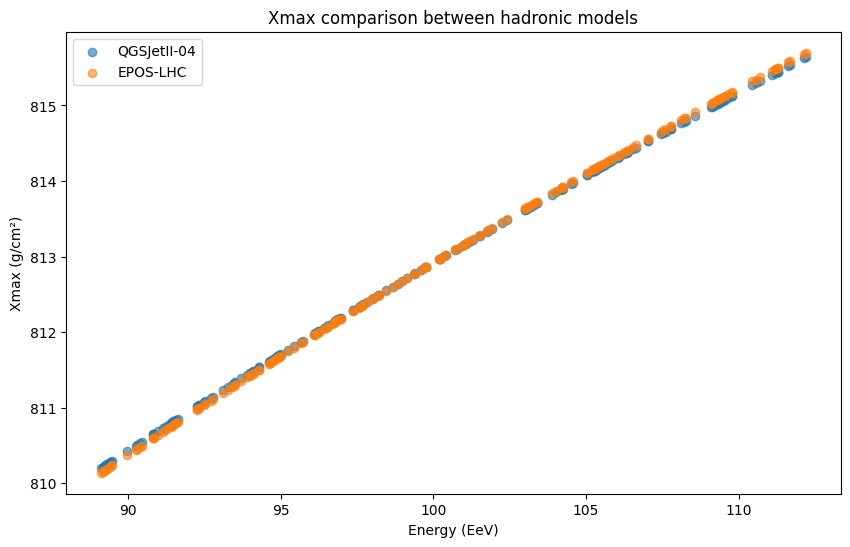

In [42]:
# Load with QGSJetII-04
data_qgs = parse_dst_file(
    dst_file,
    xmax_reader=XmaxReader(dst_dir, model="QGSJetII-04")
)

# Load with EPOS-LHC
data_epos = parse_dst_file(
    dst_file,
    xmax_reader=XmaxReader(dst_dir, model="EPOS-LHC")
)

# Compare Xmax predictions
plt.figure(figsize=(10, 6))
plt.scatter(data_qgs["energy"], data_qgs["xmax"], label="QGSJetII-04", alpha=0.6)
plt.scatter(data_epos["energy"], data_epos["xmax"], label="EPOS-LHC", alpha=0.6)
plt.xlabel("Energy (EeV)")
plt.ylabel("Xmax (g/cm²)")
plt.legend()
plt.title("Xmax comparison between hadronic models")
plt.show()

### 1.8 Visualizing Detector Layouts

#### Transformed coordinates (shower-centric)

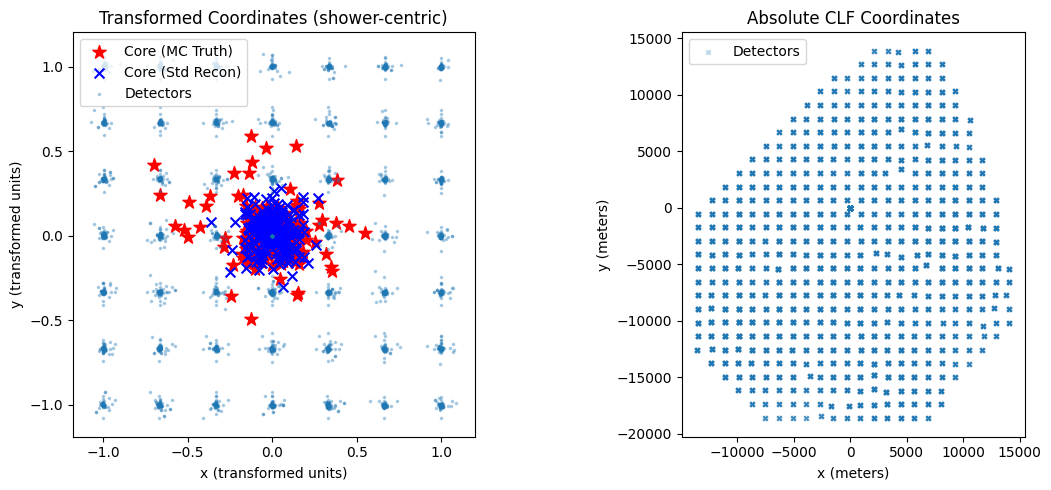

In [43]:
data = parse_dst_file(dst_file)

plt.figure(figsize=(12, 5))

# Transformed coordinates (centered on shower)
plt.subplot(1, 2, 1)
plt.scatter(data["shower_core"][:, 0], data["shower_core"][:, 1], 
           label="Core (MC Truth)", s=100, marker='*', c='red')
plt.scatter(data["std_recon_shower_core"][:, 0], data["std_recon_shower_core"][:, 1], 
           label="Core (Std Recon)", s=50, marker='x', c='blue')
plt.scatter(data["detector_positions"][..., 0], data["detector_positions"][..., 1], 
           marker=".", alpha=0.3, label="Detectors", s=10)
plt.xlabel("x (transformed units)")
plt.ylabel("y (transformed units)")
plt.gca().set_aspect("equal")
plt.legend()
plt.title("Transformed Coordinates (shower-centric)")

# Absolute coordinates (CLF frame in meters)
plt.subplot(1, 2, 2)
plt.scatter(data["detector_positions_abs"][..., 0], data["detector_positions_abs"][..., 1], 
           marker="x", alpha=0.3, label="Detectors", s=10)
plt.xlabel("x (meters)")
plt.ylabel("y (meters)")
plt.gca().set_aspect("equal")
plt.legend()
plt.title("Absolute CLF Coordinates")

plt.tight_layout()
plt.show()

### 1.9 Accessing Event Data

Simple direct indexing:

In [45]:
from dstparser.std_qcuts import angular_dist

event_idx = 0

# Get all data for one event
signals = data['total_signals'][event_idx]          # (7, 7)
times = data['arrival_times'][event_idx]            # (7, 7)
positions = data['detector_positions'][event_idx]   # (7, 7, 3)
traces = data['time_traces'][event_idx]             # (7, 7, 128)

# Find active detectors (non-zero signal)
active = signals > 0
n_active = np.sum(active)

print(f"Event {event_idx}:")
print(f"  Energy: {data['energy'][event_idx]:.3f} EeV")
print(f"  Zenith: {angular_dist(data['shower_axis'][event_idx])[0]:.1f}°")
print(f"  Active detectors: {n_active} out of 49")
print(f"  Signal range: {signals[active].min():.2f} - {signals[active].max():.2f} VEM")

Event 0:
  Energy: 94.747 EeV
  Zenith: 40.6°
  Active detectors: 18 out of 49
  Signal range: 1.47 - 14141.75 VEM


### 1.10 Quality Cuts

Apply standard spectrum quality cuts:

In [46]:
from dstparser.std_qcuts import std_spectrum_quality_cuts

# Load with standard reconstruction
data = parse_dst_file(dst_file)

# Apply quality cuts
qcut_mask = std_spectrum_quality_cuts(data)

print(f"Events before cuts: {len(data['energy'])}")
print(f"Events passing cuts: {np.sum(qcut_mask)}")
print(f"Pass rate: {100 * np.sum(qcut_mask) / len(data['energy']):.1f}%")

# Filter data
qdata = {key: data[key][qcut_mask] for key in data}
print(f"\nFiltered data has {len(qdata['energy'])} events")

Total = 192
cut                 : efficiency,  combined,      after cut
-----------------------------------------------------------
nsd                 :    97.40%,    97.40%,            187
zenith              :    97.40%,    96.35%,            185
dborder             :    61.98%,    61.98%,            119
tshape_border       :    98.96%,    61.46%,            118
point_dir           :    89.06%,    60.94%,            117
chi2_geom           :    97.40%,    60.94%,            117
chi2_ldf            :    89.58%,    59.38%,            114
s800_err            :    82.29%,    59.38%,            114
Events before cuts: 192
Events passing cuts: 114
Pass rate: 59.4%

Filtered data has 114 events


## Part 2: Variable-Length Format (`parse_dst_file_vlen`)

### 2.1 Why Variable-Length?

The variable-length format:
- ✓ Uses less memory (no zero-padding)
- ✓ Preserves original detector coordinates
- ✓ Handles varying number of detectors per event
- ✓ Ideal for Graph Neural Networks
- ✗ Requires offset management to access data

### 2.2 Basic Usage

In [47]:
# Parse in variable-length format
data_vlen = parse_dst_file_vlen(dst_file)

print("Variable-length format data:")
print_data_info(data_vlen)

Variable-length format data:
mass_number.shape=(192,), dtype=int32, size=0.001 MB
energy.shape=(192,), dtype=float64, size=0.001 MB
shower_axis.shape=(192, 3), dtype=float64, size=0.004 MB
shower_core.shape=(192, 3), dtype=float64, size=0.004 MB
std_recon_yymmdd.shape=(192,), dtype=int64, size=0.001 MB
std_recon_hhmmss.shape=(192,), dtype=int64, size=0.001 MB
std_recon_usec.shape=(192,), dtype=int64, size=0.001 MB
std_recon_nofwf.shape=(192,), dtype=int32, size=0.001 MB
std_recon_nsd.shape=(192,), dtype=int32, size=0.001 MB
std_recon_nsclust.shape=(192,), dtype=int32, size=0.001 MB
std_recon_nhits.shape=(192,), dtype=int32, size=0.001 MB
std_recon_nborder.shape=(192,), dtype=float64, size=0.001 MB
std_recon_qtot.shape=(192, 2), dtype=float64, size=0.003 MB
std_recon_energy.shape=(192,), dtype=float64, size=0.001 MB
std_recon_ldf_scale.shape=(192,), dtype=float64, size=0.001 MB
std_recon_ldf_scale_err.shape=(192,), dtype=float64, size=0.001 MB
std_recon_ldf_chi2.shape=(192,), dtype=floa

### 2.3 Understanding the Offset System

The variable-length format uses **two levels of offsets**:

1. **`hit_offsets`**: Splits hit-level arrays by event
   - Length: `(n_events + 1,)`
   - Usage: `data['field'][hit_offsets[i]:hit_offsets[i+1]]` gives hits for event i

2. **`hit_tt_offsets`**: Splits time trace windows by hit
   - Length: `(total_hits + 1,)`
   - Usage: `data['time_traces'][hit_tt_offsets[j]:hit_tt_offsets[j+1]]` gives windows for hit j

#### Why this structure?
- Each event has a variable number of triggered detectors (hits)
- Each hit can have multiple time trace windows (stored in `nfold` field)
- Flat arrays are memory-efficient and allow fast slicing

In [48]:
# Examine offset structure
n_events = len(data_vlen['hit_offsets']) - 1
total_hits = data_vlen['hit_offsets'][-1]
total_windows = data_vlen['hit_tt_offsets'][-1]

print(f"Number of events: {n_events}")
print(f"Total hits: {total_hits}")
print(f"Total time trace windows: {total_windows}")
print(f"\nAverage hits per event: {total_hits / n_events:.1f}")
print(f"Average windows per hit: {total_windows / total_hits:.1f}")

Number of events: 192
Total hits: 3519
Total time trace windows: 5769

Average hits per event: 18.3
Average windows per hit: 1.6


### 2.4 Parsing Options

In [49]:
# Parse with only detector data (no MC truth or std recon)
data_vlen_minimal = parse_dst_file_vlen(
    dst_file,
    add_shower_params=False,
    add_standard_recon=False
)

print("\nMinimal variable-length data (detector readings only):")
print_data_info(data_vlen_minimal)


Minimal variable-length data (detector readings only):
arrival_times.shape=(3519, 2), dtype=float64, size=0.054 MB
pulse_area.shape=(3519, 2), dtype=float64, size=0.054 MB
detector_positions.shape=(3519, 3), dtype=float64, size=0.081 MB
status.shape=(3519,), dtype=int32, size=0.013 MB
nfold.shape=(3519,), dtype=int32, size=0.013 MB
detector_ids.shape=(3519,), dtype=int32, size=0.013 MB
hit_offsets.shape=(193,), dtype=int64, size=0.001 MB
hit_tt_offsets.shape=(3520,), dtype=int64, size=0.027 MB
time_traces.shape=(5769, 2, 128), dtype=float32, size=5.634 MB
tt_offsets.shape=(193,), dtype=int64, size=0.001 MB
---
Total size = 5.89 MB



### 2.5 Field Descriptions

#### Event-level arrays (length = n_events):
- `energy`, `shower_axis`: MC truth
- `std_recon_*`: Standard reconstruction results
- `hit_offsets`: Boundaries for splitting hit-level arrays

#### Hit-level arrays (length = total_hits):
- `arrival_times`: (total_hits, 2) - Arrival times [lower, upper] PMT in nsec
- `pulse_area`: (total_hits, 2) - Integrated pulse [lower, upper] in VEM
- `detector_positions`: (total_hits, 3) - [x, y, z] in CLF frame (×1200m)
- `detector_ids`: (total_hits,) - Detector ID (xxyy format)
- `status`: (total_hits,) - Quality status (3=passed pattern, 4=in event, 5=saturated)
- `nfold`: (total_hits,) - Number of time trace windows per hit
- `hit_tt_offsets`: Boundaries for splitting time traces

#### Time trace arrays (length = total_windows):
- `time_traces`: (total_windows, 2, 128) - FADC waveforms [lower, upper] × 128 samples

### 2.6 Accessing Data for a Single Event

In [50]:
evt_idx = 20

# Get event boundaries
hits_start = data_vlen["hit_offsets"][evt_idx]
hits_end = data_vlen["hit_offsets"][evt_idx + 1]
n_hits = hits_end - hits_start

# Extract hit-level data for this event
pulse_area = data_vlen["pulse_area"][hits_start:hits_end]        # (n_hits, 2)
positions = data_vlen["detector_positions"][hits_start:hits_end]  # (n_hits, 3)
det_ids = data_vlen["detector_ids"][hits_start:hits_end]         # (n_hits,)
nfolds = data_vlen["nfold"][hits_start:hits_end]                 # (n_hits,)

print(f"Event {evt_idx}:")
print(f"  Energy: {data_vlen['energy'][evt_idx]:.3f} EeV")
print(f"  Number of hits: {n_hits}")
print(f"  Detector IDs: {det_ids}")
print(f"  Pulse areas (VEM): {pulse_area[:, 0]}  (lower PMT)")
print(f"  Number of time trace windows per hit: {nfolds}")

Event 20:
  Energy: 101.044 EeV
  Number of hits: 23
  Detector IDs: [1206 1207 1208 1305 1306 1307 1308 1404 1405 1406 1407 1408 1409 1505
 1506 1507 1508 1509 1606 1607 1608 1706 1707]
  Pulse areas (VEM): [4.57721100e+00 4.00796300e+00 1.68532900e+00 1.59721300e+00
 5.00093990e+01 7.22862740e+01 9.07277980e+01 3.53117000e+00
 1.41487980e+01 4.13986303e+02 5.26612145e+03 3.22166450e+01
 8.46285000e+00 1.15659390e+01 3.50239553e+02 1.96377242e+02
 1.12711140e+01 1.74718900e+00 2.94776880e+01 3.54686540e+01
 5.62278400e+00 2.43947400e+00 8.95787000e-01]  (lower PMT)
  Number of time trace windows per hit: [1 1 1 1 1 2 2 1 2 3 3 2 1 2 3 2 1 1 2 2 2 1 1]


### 2.7 Accessing Time Traces

Time traces require two-level indexing:

In [51]:
evt_idx = 9

# Step 1: Get hits for this event
hits_start = data_vlen["hit_offsets"][evt_idx]
hits_end = data_vlen["hit_offsets"][evt_idx + 1]

# Step 2: Get time trace boundaries for these hits
tt_start = data_vlen["hit_tt_offsets"][hits_start]
tt_end = data_vlen["hit_tt_offsets"][hits_end]

# Step 3: Extract time traces
ttrace = data_vlen["time_traces"][tt_start:tt_end]  # (n_windows, 2, 128)

print(f"Event {evt_idx}:")
print(f"  Time traces shape: {ttrace.shape}")
print(f"  (n_windows, 2 PMTs, 128 samples)")

# Verify total windows matches sum of nfolds
nfolds = data_vlen["nfold"][hits_start:hits_end]
print(f"  Total windows: {ttrace.shape[0]}")
print(f"  Sum of nfolds: {np.sum(nfolds)}")
print(f"  Match: {ttrace.shape[0] == np.sum(nfolds)}")

Event 9:
  Time traces shape: (39, 2, 128)
  (n_windows, 2 PMTs, 128 samples)
  Total windows: 39
  Sum of nfolds: 39
  Match: True


### 2.8 Splitting Time Traces by Hit

Each hit can have multiple time trace windows. Here's how to split them:

In [34]:
ttrace.shape

(11, 2, 128)

In [30]:
windows_offsets = np.cumsum([0] + nfolds)
split_ttraces =np.split(ttrace, windows_offsets[1:-1])

In [31]:
len(split_ttraces)

7

In [53]:
evt_idx = 9
hits_start = data_vlen["hit_offsets"][evt_idx]
hits_end = data_vlen["hit_offsets"][evt_idx + 1]

# Get time traces for this event
tt_start = data_vlen["hit_tt_offsets"][hits_start]
tt_end = data_vlen["hit_tt_offsets"][hits_end]
ttrace = data_vlen["time_traces"][tt_start:tt_end]

# Get nfolds (number of windows per hit)
nfolds = data_vlen["nfold"][hits_start:hits_end]

# Create split indices
windows_offsets = np.cumsum([0] + list(nfolds))

# Split into list of arrays (one per hit)
split_ttraces = np.split(ttrace, windows_offsets[1:-1])

print(f"Event {evt_idx} has {len(split_ttraces)} hits")
for ihit, hit_traces in enumerate(split_ttraces[:5]):
    print(f"  Hit {ihit}: {hit_traces.shape} (n_windows, 2, 128)")

Event 9 has 23 hits
  Hit 0: (1, 2, 128) (n_windows, 2, 128)
  Hit 1: (1, 2, 128) (n_windows, 2, 128)
  Hit 2: (1, 2, 128) (n_windows, 2, 128)
  Hit 3: (2, 2, 128) (n_windows, 2, 128)
  Hit 4: (3, 2, 128) (n_windows, 2, 128)


In [54]:
len(split_ttraces)

23

### 2.9 Visualizing Time Traces

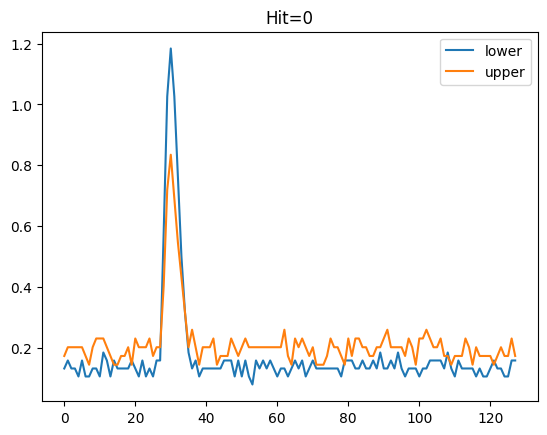

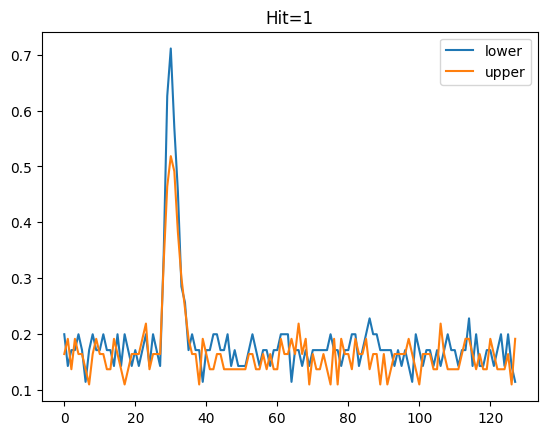

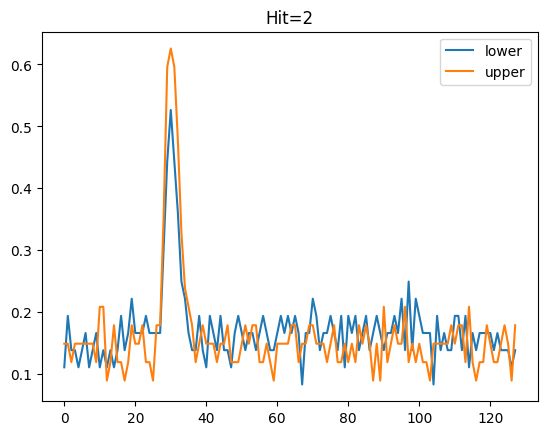

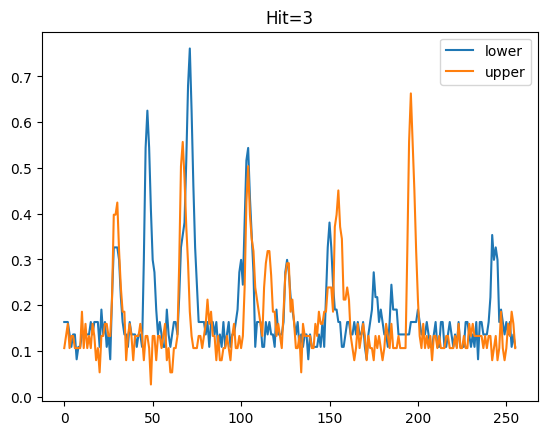

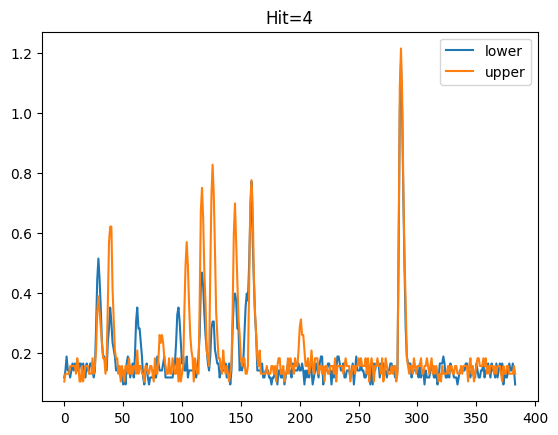

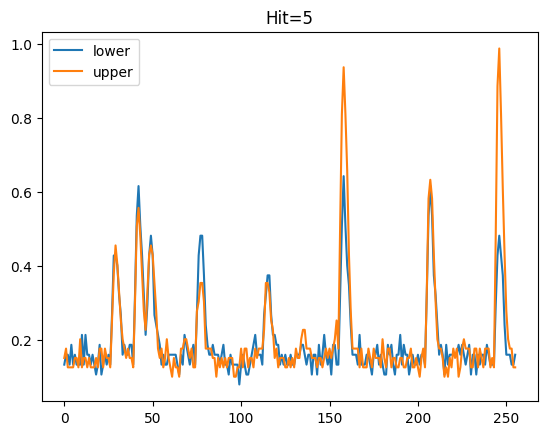

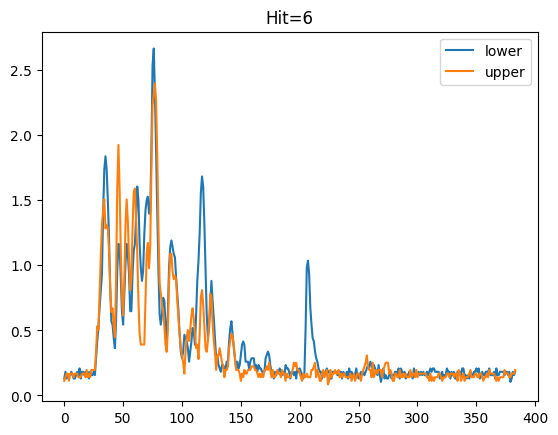

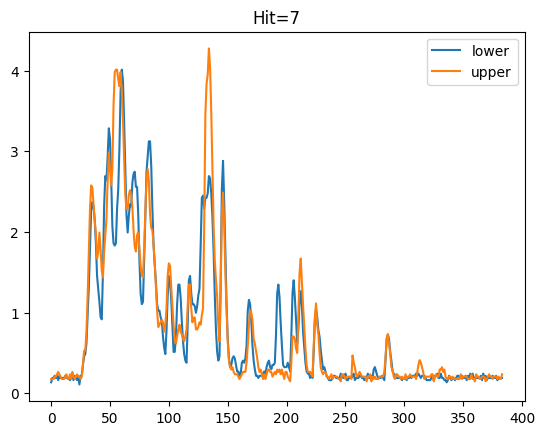

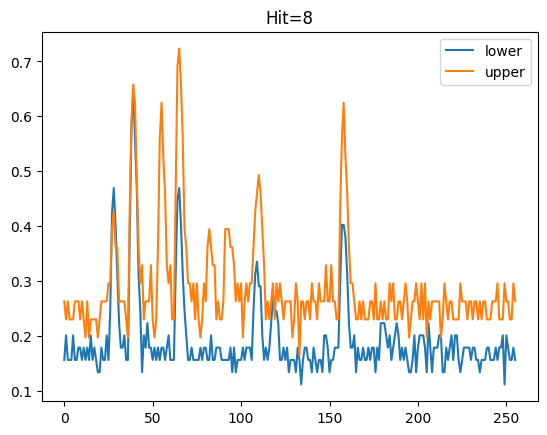

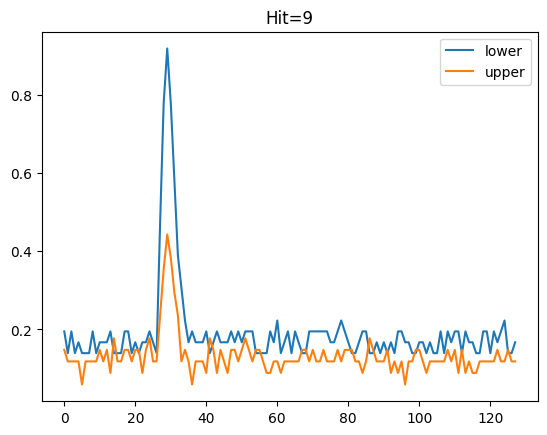

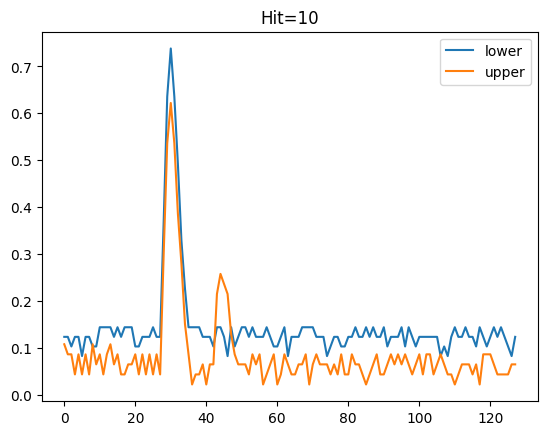

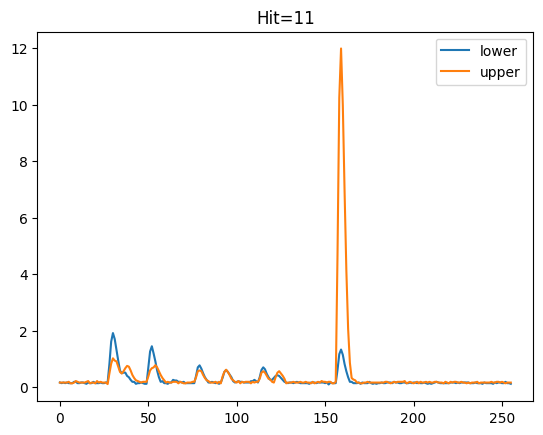

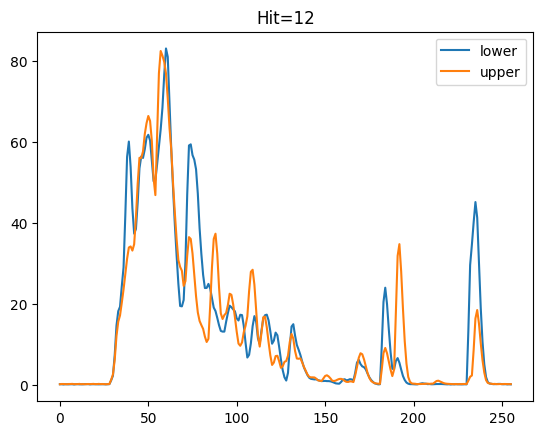

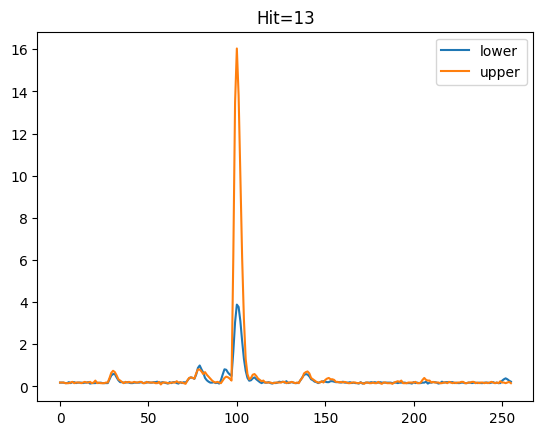

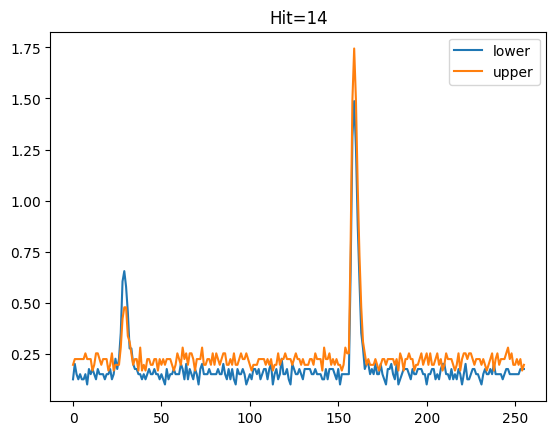

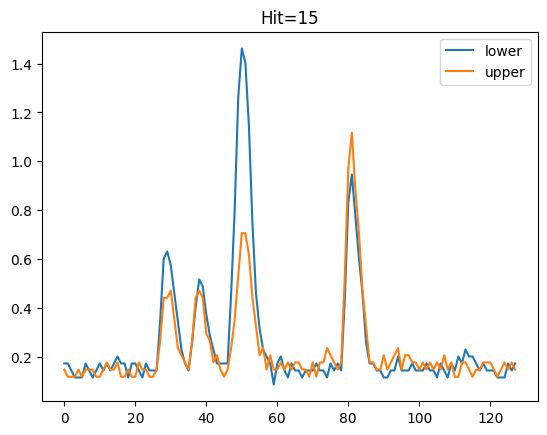

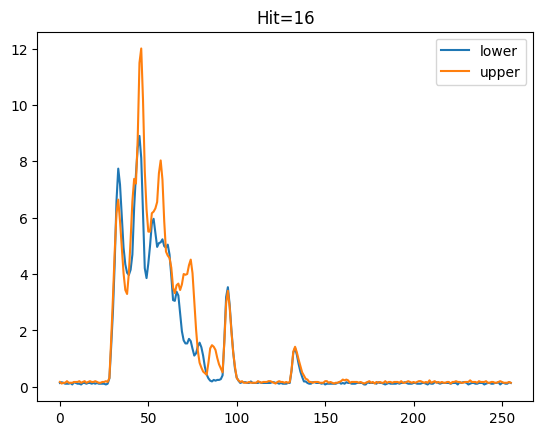

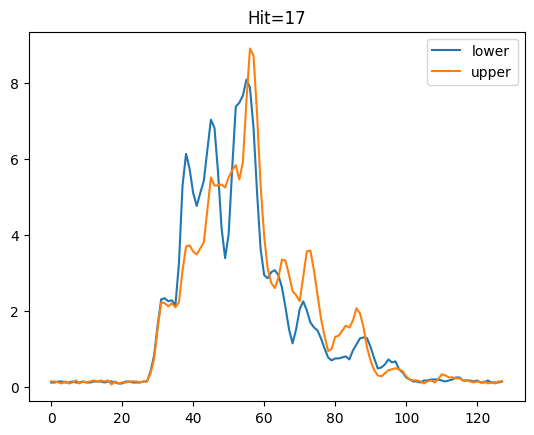

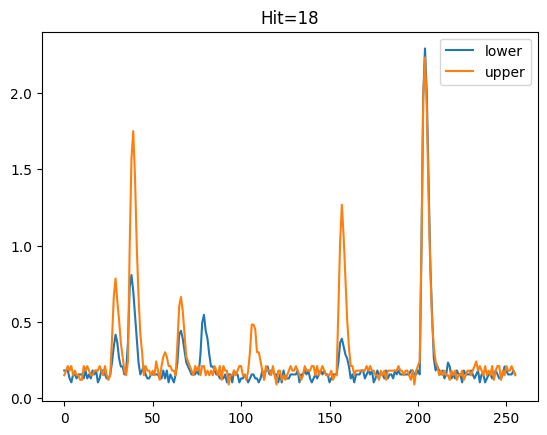

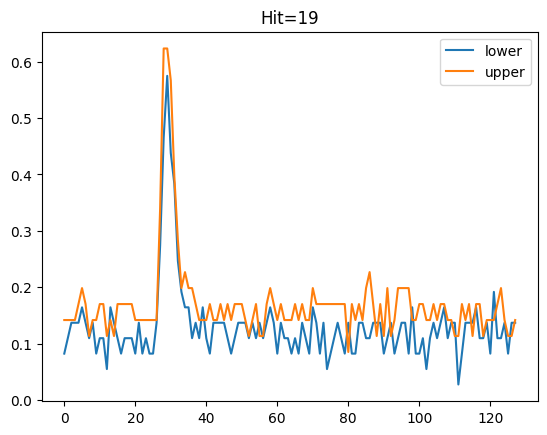

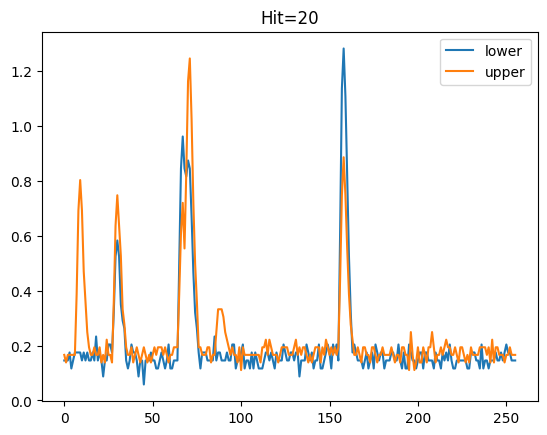

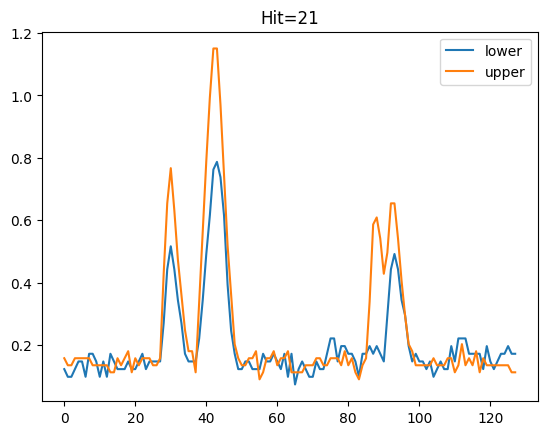

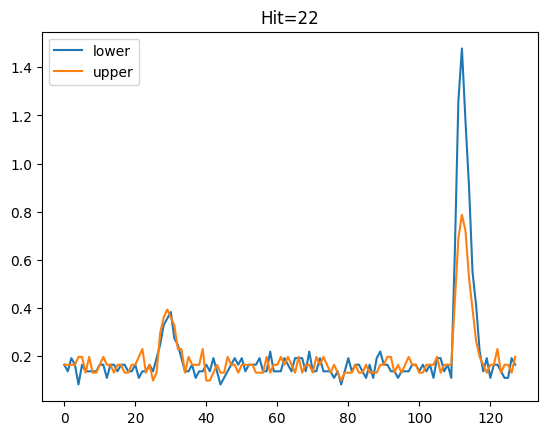

In [56]:
for ihit in range(len(split_ttraces)):
    joined_ttraces = split_ttraces[ihit].transpose(1, 0, 2).reshape(2, -1)
    plt.plot(joined_ttraces[0], label = "lower")
    plt.plot(joined_ttraces[1], label = "upper")
    plt.title(f"Hit={ihit}")
    plt.legend()
    plt.show()

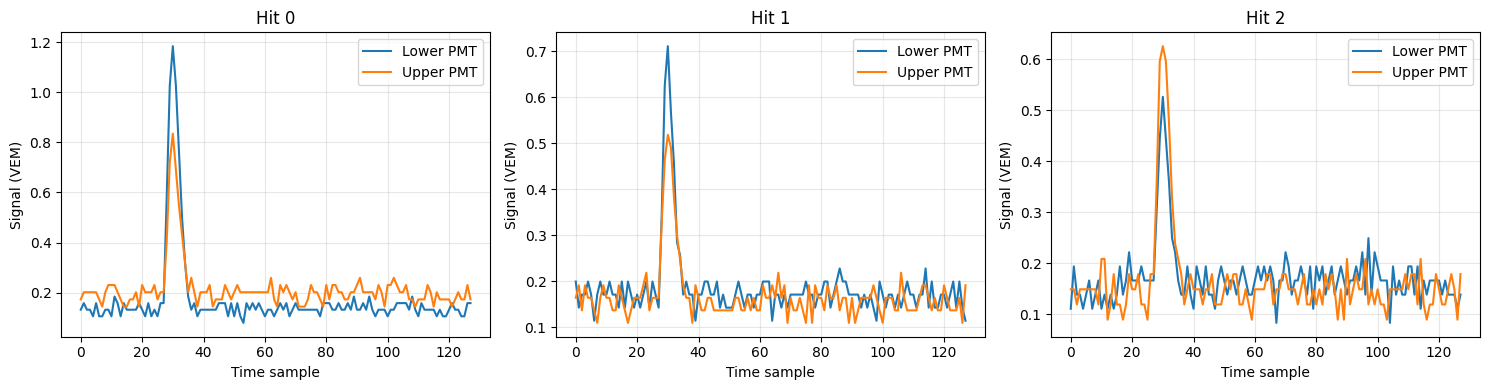

In [65]:
# Plot time traces for first 3 hits
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ihit in range(min(3, len(split_ttraces))):
    # Join multiple windows into one continuous trace
    # Shape: (n_windows, 2, 128) -> (2, n_windows * 128)
    joined_ttraces = split_ttraces[ihit].transpose(1, 0, 2).reshape(2, -1)
    joined_ttraces = split_ttraces[ihit].transpose(1, 0, 2).reshape(2, -1)
    
    axes[ihit].plot(joined_ttraces[0], label="Lower PMT")
    axes[ihit].plot(joined_ttraces[1], label="Upper PMT")
    axes[ihit].set_title(f"Hit {ihit}")
    axes[ihit].set_xlabel("Time sample")
    axes[ihit].set_ylabel("Signal (VEM)")
    axes[ihit].legend()
    axes[ihit].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.10 Statistics Across Events

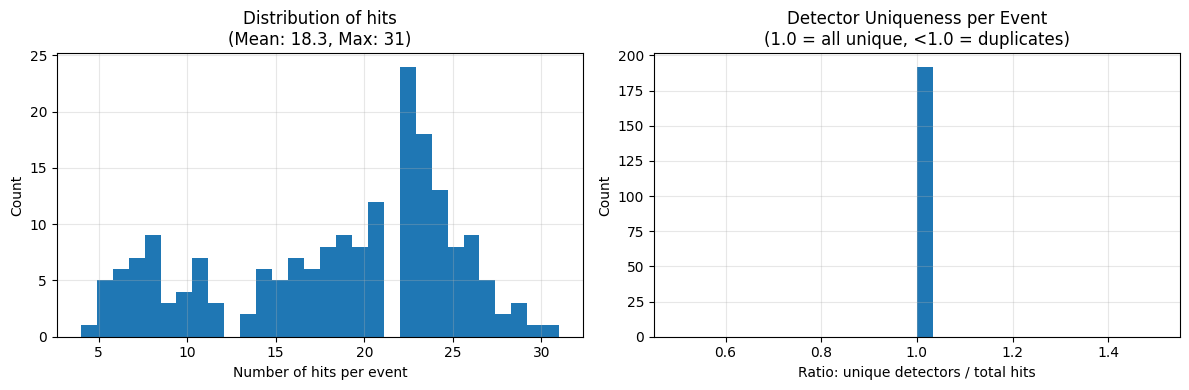

Events with duplicate detector IDs: 0
(This can happen when same detector has multiple time windows)


In [69]:
# Distribution of hits per event
event_lens = np.diff(data_vlen["hit_offsets"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(event_lens, bins=30)
plt.xlabel("Number of hits per event")
plt.ylabel("Count")
plt.title(f"Distribution of hits\n(Mean: {event_lens.mean():.1f}, Max: {event_lens.max()})")
plt.grid(True, alpha=0.3)

# Check for duplicate detectors in events
plt.subplot(1, 2, 2)
unique_ratios = []
for evt_idx in range(len(event_lens)):
    start = data_vlen["hit_offsets"][evt_idx]
    end = data_vlen["hit_offsets"][evt_idx + 1]
    det_ids = data_vlen["detector_ids"][start:end]
    unique_ratios.append(len(np.unique(det_ids)) / len(det_ids))

plt.hist(unique_ratios, bins=30)
plt.xlabel("Ratio: unique detectors / total hits")
plt.ylabel("Count")
plt.title("Detector Uniqueness per Event\n(1.0 = all unique, <1.0 = duplicates)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Events with duplicate detector IDs: {sum(r < 1.0 for r in unique_ratios)}")
print(f"(This can happen when same detector has multiple time windows)")

### 2.11 Visualizing Event Footprints

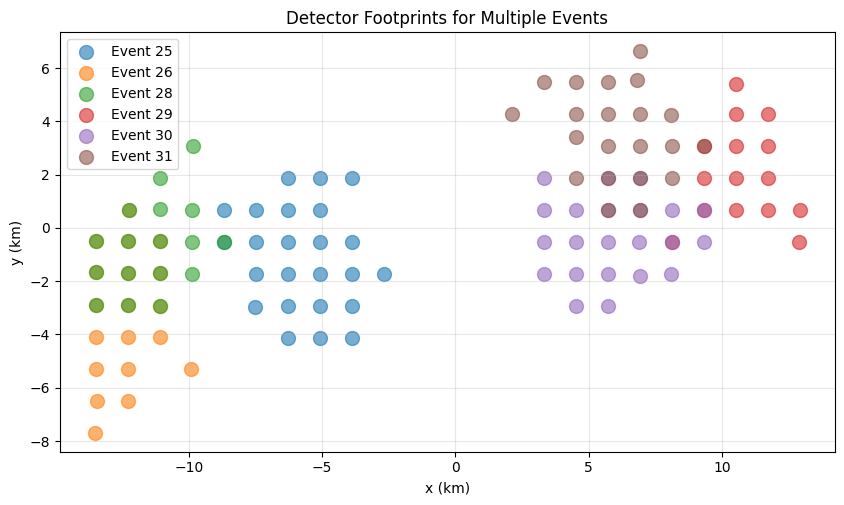

In [70]:
# Plot detector positions for multiple events
plt.figure(figsize=(10, 8))

for evt_idx in [25, 26, 28, 29, 30, 31]:
    hits_start = data_vlen["hit_offsets"][evt_idx]
    hits_end = data_vlen["hit_offsets"][evt_idx + 1]
    
    # Convert from 1200m units to km
    det_pos = data_vlen["detector_positions"][hits_start:hits_end] * 1200 / 1000
    
    plt.scatter(det_pos[:, 0], det_pos[:, 1], label=f"Event {evt_idx}", s=100, alpha=0.6)

plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Detector Footprints for Multiple Events")
plt.gca().set_aspect("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2.12 All Detectors from All Events

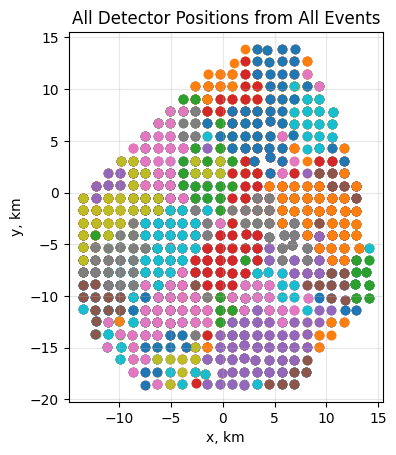

In [74]:
for evt_idx in range(data_vlen["hit_offsets"].shape[0]-1):
    hits_start = data_vlen["hit_offsets"][evt_idx]
    hits_end = data_vlen["hit_offsets"][evt_idx+1]
    det_pos = data_vlen["detector_positions"][hits_start:hits_end]*1200/1000
    plt.scatter(det_pos[:,0], det_pos[:,1])
    plt.xlabel("x, km")
    plt.ylabel("y, km")
# plt.gca().set_aspect("equal")
plt.title("All Detector Positions from All Events")
plt.gca().set_aspect("equal")
plt.grid(True, alpha=0.3)
plt.show()

## Part 3: Working with Multiple Files

### 3.1 Finding DST Files

In [75]:
# Search for all DST files in directory
glob_pattern = "DAT*dst.gz"
dst_files = sorted([str(file) for file in Path(dst_dir).rglob(glob_pattern)])

print(f"Found {len(dst_files)} DST files")
print("\nFirst 5 files:")
for f in dst_files[:5]:
    print(f"  {Path(f).name}")

Found 33000 DST files

First 5 files:
  DAT000000_gea.rufldf.dst.gz
  DAT000001_gea.rufldf.dst.gz
  DAT000002_gea.rufldf.dst.gz
  DAT000003_gea.rufldf.dst.gz
  DAT000004_gea.rufldf.dst.gz


### 3.2 Accumulating Data from Multiple Files (Structured Format)

In [76]:
# Parse first 10 files and accumulate data
acc_data = dict()
xmax_reader = XmaxReader(dst_dir)

for dst_file in dst_files[0:10]:
    data = parse_dst_file(
        dst_file,
        ntile=7,
        xmax_reader=xmax_reader,
        avg_traces=False,
        add_shower_params=True,
        add_standard_recon=False,
    )

    if data is None:
        continue

    # Accumulate each field
    for key, value in data.items():
        acc_data.setdefault(key, []).append(value)

print(f"Accumulated data from {len(dst_files[0:10])} files")
print(f"Total events: {sum(len(arr) for arr in acc_data['energy'])}")

Accumulated data from 10 files
Total events: 1393


### 3.3 Saving to HDF5

HDF5 is an efficient format for storing large datasets:

In [77]:
from dstparser.cli.io import save2hdf5, read_h5
from dstparser.read_data import read_hdf5_metadata
import os

output_file = "/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/outres.h5"

# Save without compression first
save2hdf5(acc_data, filename=output_file, compress_arrs=[])

print("\nSaved data metadata:")
read_hdf5_metadata(output_file)

print(f"\nFile size without compression: {os.path.getsize(output_file)/1024**2:.2f} MB")


Saved data metadata:

File size without compression: 70.03 MB


### 3.4 Compression Options

Compress specific arrays to reduce file size:

In [78]:
# Save with compression on time-related arrays
save2hdf5(
    acc_data,
    filename=output_file,
    compress_arrs=["time", "arrival", "detector"]  # Compress arrays with these substrings
)

print("\nWith compression:")
read_hdf5_metadata(output_file)

print(f"\nFile size with compression: {os.path.getsize(output_file)/1024**2:.2f} MB")


With compression:

File size with compression: 12.02 MB


### 3.5 Reading from HDF5

In [79]:
# Read back from HDF5
data_from_h5 = read_h5(output_file)

print("Data loaded from HDF5:")
print_data_info(data_from_h5)

Data loaded from HDF5:
arrival_times_low.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
arrival_times_up.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
detector_exists.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
detector_good.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
detector_positions.shape=(1393, 7, 7, 3), dtype=float32, size=0.781 MB
detector_positions_abs.shape=(1393, 7, 7, 3), dtype=float32, size=0.781 MB
detector_positions_id.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
detector_states.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
energy.shape=(1393,), dtype=float32, size=0.005 MB
mass_number.shape=(1393,), dtype=int32, size=0.005 MB
nfold.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
shower_axis.shape=(1393, 3), dtype=float32, size=0.016 MB
shower_core.shape=(1393, 3), dtype=float32, size=0.016 MB
time_traces_low.shape=(1393, 7, 7, 128), dtype=float32, size=33.329 MB
time_traces_up.shape=(1393, 7, 7, 128), dtype=float32, size=33.329 MB
total_signals_low

## Part 4: Variable-Length Format with HDF5

### 4.1 Saving Variable-Length Data

For variable-length format, use `append_to_hdf5` for efficient incremental saving:

In [82]:
import h5py
from dstparser import append_to_hdf5

output_file_vlen = "/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/vlen_outres1.h5"

# Open HDF5 file and append data from multiple DST files
with h5py.File(output_file_vlen, "w") as f:  # 'w' creates new file
    for dst_file in dst_files[0:10]:
        data = parse_dst_file_vlen(
            dst_file,
            xmax_reader=XmaxReader(dst_dir),
            add_shower_params=True,
            add_standard_recon=True,
        )

        if data is None:
            continue
            
        append_to_hdf5(f, data)

print("\nVariable-length data saved to HDF5:")
read_hdf5_metadata(output_file_vlen)
print(f"\nFile size: {os.path.getsize(output_file_vlen)/1024**2:.2f} MB")


Variable-length data saved to HDF5:

File size: 11.37 MB


### 4.2 Using H5DST Helper Class

The `H5DST` class provides convenient access to variable-length HDF5 files with automatic offset handling:

In [83]:
from dstparser import H5DST

# Open file with H5DST wrapper
rdata_vlen = H5DST(output_file_vlen)

# List available fields
print("Available fields:")
for field in rdata_vlen.keys():
    print(f"  {field}")

Available fields:
  arrival_times
  detector_ids
  detector_positions
  energy
  hit_offsets
  hit_tt_offsets
  mass_number
  nfold
  pulse_area
  shower_axis
  shower_core
  status
  std_recon_border_distance
  std_recon_border_distance_tshape
  std_recon_curvature
  std_recon_curvature_err
  std_recon_energy
  std_recon_geom_chi2
  std_recon_geom_ndof
  std_recon_hhmmss
  std_recon_ldf_chi2
  std_recon_ldf_ndof
  std_recon_ldf_scale
  std_recon_ldf_scale_err
  std_recon_nborder
  std_recon_nhits
  std_recon_nofwf
  std_recon_nsclust
  std_recon_nsd
  std_recon_qtot
  std_recon_s800
  std_recon_shower_axis
  std_recon_shower_axis_err
  std_recon_shower_core
  std_recon_shower_core_err
  std_recon_usec
  std_recon_yymmdd
  time_traces
  tt_offsets
  xmax


### 4.3 Accessing Data with H5DST

H5DST handles offsets automatically:

Energy array type: <class 'h5py._hl.dataset.Dataset'>
Energy array shape: (1393,)


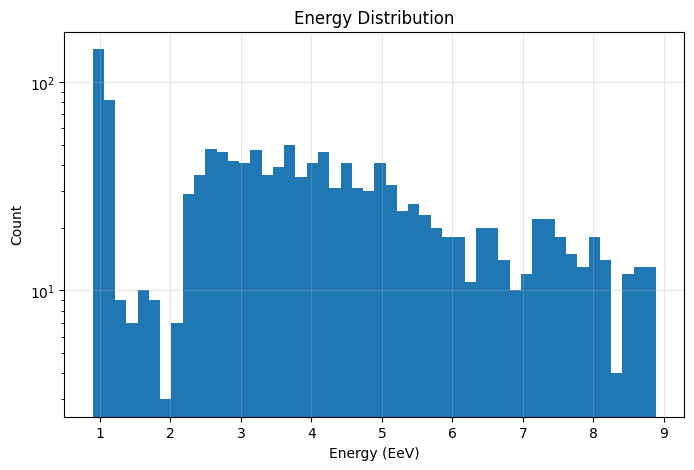

In [84]:
# Event-level data (simple array access)
energies = rdata_vlen["energy"]
print(f"Energy array type: {type(energies)}")
print(f"Energy array shape: {energies.shape}")

# Plot energy distribution
plt.figure(figsize=(8, 5))
plt.hist(energies, bins=50)
plt.xlabel("Energy (EeV)")
plt.ylabel("Count")
plt.title("Energy Distribution")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

### 4.4 Two-Level Indexing with H5DST

H5DST automatically handles offset indexing:

In [85]:
evt_idx = 1392

# Get time traces for one event (H5DST handles hit_offsets automatically)
time_traces_event = rdata_vlen["time_traces"][evt_idx]

print(f"Event {evt_idx}:")
print(f"  Number of hits: {len(time_traces_event)}")
print(f"  Type: {type(time_traces_event)}")

# Access specific hit
hit_idx = 2
time_trace_hit = rdata_vlen["time_traces"][evt_idx, hit_idx]

print(f"\n  Hit {hit_idx}:")
print(f"    Time trace shape: {time_trace_hit.shape}")
print(f"    (n_windows, 2 PMTs, 128 samples)")

Event 1392:
  Number of hits: 5
  Type: <class 'dstparser.h5dst.h5dst.ListWLen'>

  Hit 2:
    Time trace shape: (3, 2, 128)
    (n_windows, 2 PMTs, 128 samples)


### 4.5 Plotting Time Traces from HDF5

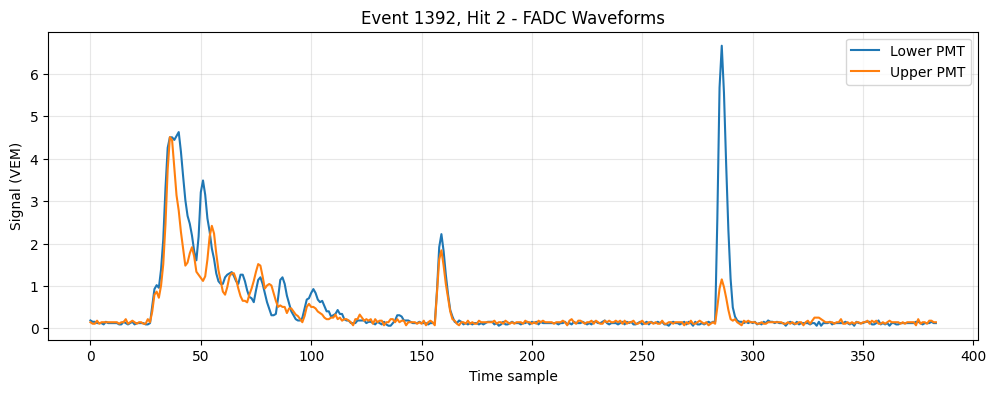

In [86]:
evt_idx = 1392
hit_idx = 2

# Get time trace
tt = rdata_vlen["time_traces"][evt_idx, hit_idx]

# Join windows: (n_windows, 2, 128) -> (2, n_windows * 128)
joined_ttraces = tt.transpose(1, 0, 2).reshape(2, -1)

plt.figure(figsize=(12, 4))
plt.plot(joined_ttraces[0], label="Lower PMT", linewidth=1.5)
plt.plot(joined_ttraces[1], label="Upper PMT", linewidth=1.5)
plt.xlabel("Time sample")
plt.ylabel("Signal (VEM)")
plt.title(f"Event {evt_idx}, Hit {hit_idx} - FADC Waveforms")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary

### Key Takeaways:

#### Structured Format (`parse_dst_file`):
- ✓ Fixed 7×7 detector grid
- ✓ Simple array indexing
- ✓ Perfect for CNNs
- ✗ Memory inefficient (zero-padding)
- ✗ Transformed coordinates

#### Variable-Length Format (`parse_dst_file_vlen`):
- ✓ Memory efficient
- ✓ Original CLF coordinates
- ✓ Preserves detector uniqueness
- ✓ Perfect for GNNs
- ✗ Requires offset management

#### Common Features:
- Both support MC truth, standard reconstruction, Xmax
- Both can be saved to HDF5 with compression
- Quality cuts available via `std_spectrum_quality_cuts`

#### HDF5 Tools:
- `save2hdf5`: Save structured data
- `append_to_hdf5`: Incrementally save variable-length data
- `H5DST`: Convenient wrapper for reading variable-length HDF5
- `MultiH5DST`: Work with multiple HDF5 files

### When to Use Each:

| Use Case | Format |
|----------|--------|
| CNN training | Structured |
| Graph Neural Networks | Variable-length |
| Memory-constrained | Variable-length |
| Need original coordinates | Variable-length |
| Simple batch processing | Structured |
| Varying detector counts | Variable-length |